#HealthNova


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/sleep_health_lifestyle.csv')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [4]:
df['Sleep Disorder'].unique()


<StringArray>
[nan, 'Sleep Apnea', 'Insomnia']
Length: 3, dtype: str

In [5]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
df['Sleep Disorder'].value_counts()

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [6]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [7]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


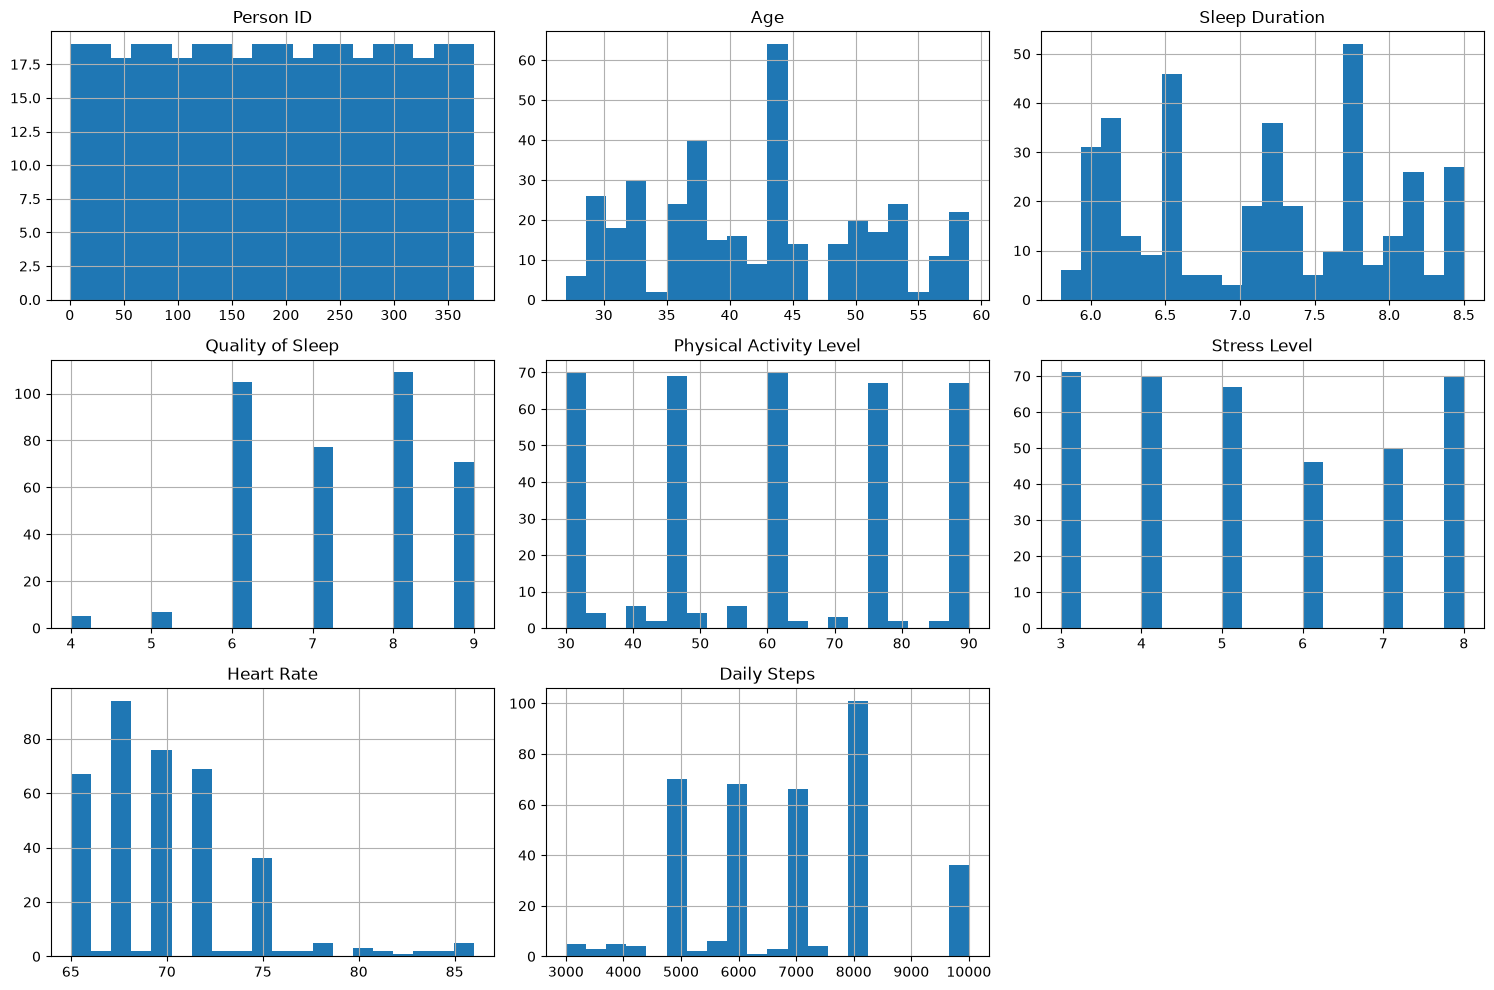

In [8]:
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

In [9]:
df['Blood Pressure'].head(10)

0    126/83
1    125/80
2    125/80
3    140/90
4    140/90
5    140/90
6    140/90
7    120/80
8    120/80
9    120/80
Name: Blood Pressure, dtype: str

In [10]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df[['Systolic_BP', 'Diastolic_BP']] = df[['Systolic_BP', 'Diastolic_BP']].astype(int)

df[['Blood Pressure', 'Systolic_BP', 'Diastolic_BP']].head()

,Blood Pressure,Systolic_BP,Diastolic_BP
0,126/83,126,83
1,125/80,125,80
2,125/80,125,80
3,140/90,140,90
4,140/90,140,90


In [11]:
df = df.drop(columns=['Blood Pressure'])
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Systolic_BP', 'Diastolic_BP'],
      dtype='str')

In [12]:
df['BMI Category'].unique()


<StringArray>
['Overweight', 'Normal', 'Obese', 'Normal Weight']
Length: 4, dtype: str

In [13]:
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
df['BMI Category'].unique()

<StringArray>
['Overweight', 'Normal', 'Obese']
Length: 3, dtype: str

Here we do Label encodigfor many things as follows
1.Gender
2. BMI Category
and one hot encoding for occupation

In [14]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})


In [15]:
df['BMI Category'] = df['BMI Category'].map({'Normal': 0, 'Overweight': 1, 'Obese': 2})


In [16]:
df = pd.get_dummies(df, columns=['Occupation'], prefix='Occupation')

In [17]:
df.head()

,Person ID,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,1,0,27,6.1,6,42,6,1,77,4200,None,126,83,False,False,False,False,False,False,False,False,False,True,False
1,2,0,28,6.2,6,60,8,0,75,10000,None,125,80,False,True,False,False,False,False,False,False,False,False,False
2,3,0,28,6.2,6,60,8,0,75,10000,None,125,80,False,True,False,False,False,False,False,False,False,False,False
3,4,0,28,5.9,4,30,8,2,85,3000,Sleep Apnea,140,90,False,False,False,False,False,False,True,False,False,False,False
4,5,0,28,5.9,4,30,8,2,85,3000,Sleep Apnea,140,90,False,False,False,False,False,False,True,False,False,False,False


In [18]:
df_model = df.drop(columns=['Person ID', 'Sleep Disorder'])
df_model.columns

Index(['Gender', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate',
       'Daily Steps', 'Systolic_BP', 'Diastolic_BP', 'Occupation_Accountant',
       'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Lawyer',
       'Occupation_Manager', 'Occupation_Nurse',
       'Occupation_Sales Representative', 'Occupation_Salesperson',
       'Occupation_Scientist', 'Occupation_Software Engineer',
       'Occupation_Teacher'],
      dtype='str')

In [19]:
X = df_model.drop(columns=['Quality of Sleep'])
y = df_model['Quality of Sleep']

print(X.shape)
print(y.shape)

(374, 21)
(374,)


In [20]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 
                 'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X.head()

,Gender,Age,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP,Occupation_Accountant,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,0,-1.753096,-1.298887,-0.825418,0.347021,1,1.654719,-1.619584,-0.330002,-0.268102,False,False,False,False,False,False,False,False,False,True,False
1,0,-1.637643,-1.173036,0.039844,1.475592,0,1.170474,1.970077,-0.459239,-0.755640,False,True,False,False,False,False,False,False,False,False,False
2,0,-1.637643,-1.173036,0.039844,1.475592,0,1.170474,1.970077,-0.459239,-0.755640,False,True,False,False,False,False,False,False,False,False,False
3,0,-1.637643,-1.550588,-1.402260,1.475592,2,3.591698,-2.362273,1.479309,0.869486,False,False,False,False,False,False,True,False,False,False,False
4,0,-1.637643,-1.550588,-1.402260,1.475592,2,3.591698,-2.362273,1.479309,0.869486,False,False,False,False,False,False,True,False,False,False,False


In [23]:
import joblib
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (299, 21) (299,)
Test set: (75, 21) (75,)


In [22]:
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

raw CSV → inspect (.info/.describe/.hist) → clean (Sleep Disorder, Blood Pressure, BMI typo)
→ encode (Label/Ordinal/One-Hot) → drop leakage/non-features → split X/y → scale → train/test split
Done till now